**Necessary Imports**

In [46]:
import pandas as pd 
import numpy as np 
import re 
import matplotlib.pyplot as plt

**Loading the Necessary Files**

In [47]:
df = pd.read_csv("../Data/car.csv")
df.head()

,Name,Price,Used For,Transmisson,Colour,Make Year,Mileage,Engine (CC),Fuel,Kilometer Run,Waranty,Types
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,"रू. 24,75,000रू. 25,00,000",Private Use,Manual2WD,Brown,2015,14,1400,Petrol,42000,NaN,NaN
1,Excellent car on sale (Hyundai),"रू. 7,50,000",NaN,Auto2WD,Light blue,2005,11,1399,Petrol,87412,NaN,NaN
2,TATA 407 Container (Tata),"रू. 7,00,000",NaN,Manual - 2WD,White,2013,NaN,2956,Diesel,60000,NaN,NaN
3,4x4 swaraj Mazda (Mahindra),"रू. 6,00,000",NaN,Manual - 4WD,NaN,2017,NaN,NaN,Diesel,NaN,NaN,NaN
4,i20 Active good for used few time (Hyundai),रू. 375,NaN,Auto - 2WD,white,2019,17,1200,Petrol,2400,NaN,NaN


**Changing the columns into Snake Case**

In [48]:
df.columns = (
    df.columns               
      .str.lower()                  # convert to lowercase
      .str.replace('[^a-zA-Z0-9 ]', '', regex=True)   # remove special chars ()&./
      .str.replace(' +', '_', regex=True)  # convert spaces to underscores
)
df.head()

,name,price,used_for,transmisson,colour,make_year,mileage,engine_cc,fuel,kilometer_run,waranty,types
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,"रू. 24,75,000रू. 25,00,000",Private Use,Manual2WD,Brown,2015,14,1400,Petrol,42000,NaN,NaN
1,Excellent car on sale (Hyundai),"रू. 7,50,000",NaN,Auto2WD,Light blue,2005,11,1399,Petrol,87412,NaN,NaN
2,TATA 407 Container (Tata),"रू. 7,00,000",NaN,Manual - 2WD,White,2013,NaN,2956,Diesel,60000,NaN,NaN
3,4x4 swaraj Mazda (Mahindra),"रू. 6,00,000",NaN,Manual - 4WD,NaN,2017,NaN,NaN,Diesel,NaN,NaN,NaN
4,i20 Active good for used few time (Hyundai),रू. 375,NaN,Auto - 2WD,white,2019,17,1200,Petrol,2400,NaN,NaN


**Dropping Duplicate**

In [49]:
df.drop_duplicates(subset=["name"], keep="first")


,name,price,used_for,transmisson,colour,make_year,mileage,engine_cc,fuel,kilometer_run,waranty,types
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,"रू. 24,75,000रू. 25,00,000",Private Use,Manual2WD,Brown,2015,14,1400,Petrol,42000,NaN,NaN
1,Excellent car on sale (Hyundai),"रू. 7,50,000",NaN,Auto2WD,Light blue,2005,11,1399,Petrol,87412,NaN,NaN
2,TATA 407 Container (Tata),"रू. 7,00,000",NaN,Manual - 2WD,White,2013,NaN,2956,Diesel,60000,NaN,NaN
3,4x4 swaraj Mazda (Mahindra),"रू. 6,00,000",NaN,Manual - 4WD,NaN,2017,NaN,NaN,Diesel,NaN,NaN,NaN
4,i20 Active good for used few time (Hyundai),रू. 375,NaN,Auto - 2WD,white,2019,17,1200,Petrol,2400,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
843,Hyundai grand i10 (Hyundai),"रू. 24,50,000",2 years,Manual - 2WD,silver,2020,2025,1200,Petrol,26500,NaN,NaN
844,Well maintained car. Everything is fine. Singl...,"रू. 19,25,000",6 years,Manual2WD,Navy blue,2015,15,1200,Petrol,60000,No,NaN
845,VW Polo 2014 Highline 1200 (Renault),"रू. 19,50,000",7,Manual2WD,Carbon Steel ( Dark Grey),2014,12 to 14,1200,Petrol,60000,NaN,NaN
846,Hyundai i10 magna 2014 (Hyundai),"रू. 17,50,000",NaN,Manual - 2WD,silver,2014,NaN,1200,Petrol,93000,NaN,NaN


**Since, [engine_cc,make_year,price] are the critical columns thus, we are dropping those entries  where 2 out of 3 columns are missing. **

In [50]:
print(df['make_year'].isna().sum())
print(df['make_year'].isna().sum())


critical_columns = ['engine_cc', 'make_year', 'price']

missing_count = df[critical_columns].isna().sum(axis=1)
to_drop = missing_count >= 2

# Optional: inspect what will be dropped
# print(df.loc[to_drop, critical_columns])

df = df.loc[~to_drop].copy()
df.shape[0]


0
0


848

**Dropping 'colour' because it has no semantic value, 'types' because it is complektely null, 'waranty' because it is mostly null and 'used_for' because it is very variable **

In [51]:
df.drop(['used_for','colour','waranty','types'],axis=1,inplace=True)

**Removing Currency Symbol**

In [52]:
df['price'] = df['price'].str.replace("रू.","",regex=False).str.replace(",","",regex=False).str.strip() #removes the rupee symbol and commas in the price. 
df.loc[0,'price']=2475000
df.head()

,name,price,transmisson,make_year,mileage,engine_cc,fuel,kilometer_run
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,2475000,Manual2WD,2015,14,1400,Petrol,42000
1,Excellent car on sale (Hyundai),750000,Auto2WD,2005,11,1399,Petrol,87412
2,TATA 407 Container (Tata),700000,Manual - 2WD,2013,NaN,2956,Diesel,60000
3,4x4 swaraj Mazda (Mahindra),600000,Manual - 4WD,2017,NaN,NaN,Diesel,NaN
4,i20 Active good for used few time (Hyundai),375,Auto - 2WD,2019,17,1200,Petrol,2400


There are some listings with name in Nepali but they are kept as it is because it is very difficult to extend semantic meaning from them. 

**Changing the transmission column into transmission_type and drive**

In [53]:
def split_transmisson(value):
    
    #first, let us check if the value is none. 
    if pd.isna(value):
        return (None,None)

    #Lets seperate by space
    value = value.strip()

    #If - is in the value then seperate by that value
    if '-' in value:
        parts = [p.strip() for p in value.split('-')]
        if len(parts) == 2:
            transmission_type = parts[0]
            drive = parts[1]
            return (transmission_type, drive)

    #Finally if the - doesn't exist we seperate alphabetic and numeric/WD parts 
    match = re.match(r"([A-Za-z]+)(.*)", value)
    if match:
        transmission_type = match.group(1)
        drive = match.group(2)
        return(transmission_type,drive)

    return(value,None)  

df[['transmisson_type','drive']] = df['transmisson'].apply(lambda x: pd.Series(split_transmisson(x)))
df.drop('transmisson', axis=1, inplace=True)
df.head() 


,name,price,make_year,mileage,engine_cc,fuel,kilometer_run,transmisson_type,drive
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,2475000,2015,14,1400,Petrol,42000,Manual,2WD
1,Excellent car on sale (Hyundai),750000,2005,11,1399,Petrol,87412,Auto,2WD
2,TATA 407 Container (Tata),700000,2013,NaN,2956,Diesel,60000,Manual,2WD
3,4x4 swaraj Mazda (Mahindra),600000,2017,NaN,NaN,Diesel,NaN,Manual,4WD
4,i20 Active good for used few time (Hyundai),375,2019,17,1200,Petrol,2400,Auto,2WD


**Some of the vehicles have engine_cc in KW (electric vehicles. Need to change them in cc)**

In [54]:
def convert_kw_to_cc(value):
    if pd.isna(value):
        return value
    
    # Convert to string for processing
    value_str = str(value).strip().lower()
    
    # Check if 'kw' is in the value
    if 'kw' in value_str:
        # Extract numeric part using regex
        match = re.search(r'(\d+\.?\d*)', value_str)
        if match:
            numeric_value = float(match.group(1))
            # Multiply by 24.25 and return
            return numeric_value * 24.25
    
    # Return original value if no 'kw' found
    return value

df['engine_cc']= df['engine_cc'].apply(convert_kw_to_cc)



**Cleaning Numeric Columns make_year, mileage, engine_cc and kilometer_run **

In [55]:


def clean_numeric_columns(df, columns):
    for col in columns:
        df[col] = df[col].astype(str).str.extract(r'(\d+(?:\.\d+)?)')
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df = clean_numeric_columns(df,['make_year','mileage','engine_cc','kilometer_run'])
df.head()


,name,price,make_year,mileage,engine_cc,fuel,kilometer_run,transmisson_type,drive
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,2475000,2015,14.0,1400.0,Petrol,42000.0,Manual,2WD
1,Excellent car on sale (Hyundai),750000,2005,11.0,1399.0,Petrol,87412.0,Auto,2WD
2,TATA 407 Container (Tata),700000,2013,NaN,2956.0,Diesel,60000.0,Manual,2WD
3,4x4 swaraj Mazda (Mahindra),600000,2017,NaN,NaN,Diesel,NaN,Manual,4WD
4,i20 Active good for used few time (Hyundai),375,2019,17.0,1200.0,Petrol,2400.0,Auto,2WD


**Discovery of Outliers in the Numeric Data**

In [56]:
def find_quartiles_and_outliers(columns):
    for column in columns:
        print(f"\n\n For the {column}")
        df[column] = pd.to_numeric(df[column],errors='coerce')
        Q1 = df[column].quantile(0.25)
        Q2 = df[column].mean()
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        print(f"Q1:{Q1} ,Q2:{Q2} ,Q3:{Q3} , IQR:{IQR}") 
        outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
        print(f"Number of Outliers: {len(outliers)}")

find_quartiles_and_outliers(['make_year','mileage','price','engine_cc','kilometer_run'])



 For the make_year
Q1:2010.0 ,Q2:1999.9870283018868 ,Q3:2017.0 , IQR:7.0
Number of Outliers: 22


 For the mileage
Q1:12.0 ,Q2:330.6473406593406 ,Q3:16.25 , IQR:4.25
Number of Outliers: 25


 For the price
Q1:1175000.0 ,Q2:2334365.9572446556 ,Q3:2650000.0 , IQR:1475000.0
Number of Outliers: 68


 For the engine_cc
Q1:1197.0 ,Q2:1520.64689608637 ,Q3:1600.0 , IQR:403.0
Number of Outliers: 112


 For the kilometer_run
Q1:32000.0 ,Q2:59069.26241134752 ,Q3:66000.0 , IQR:34000.0
Number of Outliers: 21


**Handling the missing Values**

Using median and mode for the numerical data. 

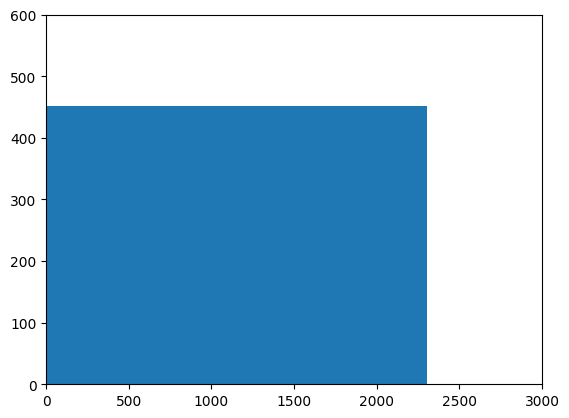

In [57]:
plt.hist(df['mileage'], bins=30)
plt.xlim(0, 3000)   # example for kilometers_run
plt.ylim(0, 600)  
plt.show()

In [58]:
df['kilometer_run'] = df['kilometer_run'].fillna(df['kilometer_run'].median())
df['engine_cc'] = df['engine_cc'].fillna(df['engine_cc'].mode()[0])
df['make_year'] = df['make_year'].fillna(df['make_year'].median())
df.head()

,name,price,make_year,mileage,engine_cc,fuel,kilometer_run,transmisson_type,drive
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,2475000.0,2015,14.0,1400.0,Petrol,42000.0,Manual,2WD
1,Excellent car on sale (Hyundai),750000.0,2005,11.0,1399.0,Petrol,87412.0,Auto,2WD
2,TATA 407 Container (Tata),700000.0,2013,NaN,2956.0,Diesel,60000.0,Manual,2WD
3,4x4 swaraj Mazda (Mahindra),600000.0,2017,NaN,1200.0,Diesel,49000.0,Manual,4WD
4,i20 Active good for used few time (Hyundai),375.0,2019,17.0,1200.0,Petrol,2400.0,Auto,2WD
